## K-Means Clustering

### Assignment 1 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma = 
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of intializing centroids randomly to the overall performance of K-means.

(600, 2)


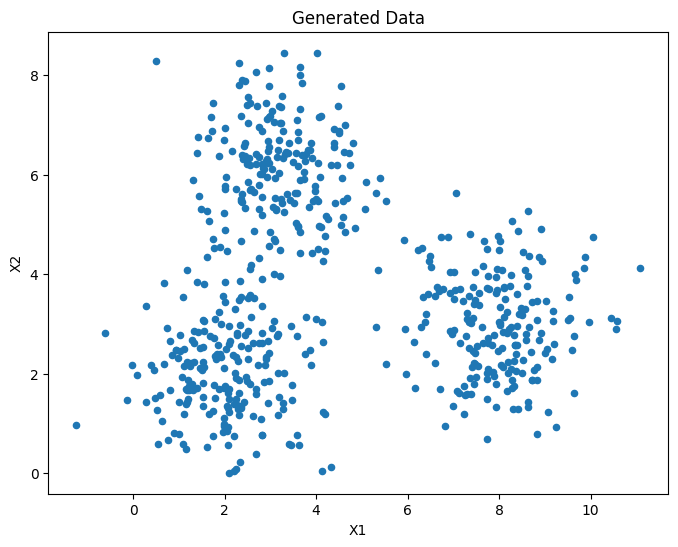

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Thiết lập seed để kết quả có thể tái lập lại
np.random.seed(42)

# Khởi tạo các tham số
N = 200
mean1 = [2, 2]
mean2 = [8, 3]
mean3 = [3, 6]
cov = [[1, 0], 
       [0, 1]]

# Tạo 3 cụm dữ liệu
cluster1 = np.random.multivariate_normal(mean1, cov, N)
cluster2 = np.random.multivariate_normal(mean2, cov, N)
cluster3 = np.random.multivariate_normal(mean3, cov, N)

# Gộp thành toy dataset cỡ (600, 2)
X = np.vstack((cluster1, cluster2, cluster3))

print(X.shape)

# Visualize

plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], s=20)

plt.title("Generated Data")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show()

In [2]:
K = 3

random_idx = np.random.choice(len(X), K, replace=False)

centroids = X[random_idx]

print("Initial Centroids:\n")
print(centroids)

Initial Centroids:

[[2.22409248 2.0125924 ]
 [2.9803622  6.55248995]
 [1.18177932 4.09238728]]


In [5]:
def assign_clusters(X, centroids):

    distances = np.linalg.norm(
        X[:, np.newaxis] - centroids,
        axis=2
    )

    #Chọn cụm gần nhất cho từng điểm
    labels = np.argmin(distances, axis=1)

    return labels


def update_centroids(X, labels, K, old_centroids):
    new_centroids = []
    for k in range(K):
        points = X[labels == k]
        if len(points) > 0:
            new_centroids.append(points.mean(axis=0))
        else:
            new_centroids.append(old_centroids[k]) # Giữ nguyên tâm cũ nếu cụm rỗng
    return np.array(new_centroids)

def compute_inertia(X, labels, centroids):

    inertia = 0

    for k in range(len(centroids)):

        cluster_points = X[labels == k]

        inertia += np.sum(
            (cluster_points - centroids[k]) ** 2
        )

    return inertia


def kmeans(X, K, max_iters=100):

    # Initialize centroids
    random_idx = np.random.choice(len(X), K, replace=False)

    centroids = X[random_idx]

    # Main loop
    for iteration in range(max_iters):

        # Step 1: Assign clusters
        labels = assign_clusters(X, centroids)

        # Step 2: Update centroids
        new_centroids = update_centroids(
            X,
            labels,
            K,
            centroids
        )

        # Check convergence
        if np.allclose(centroids, new_centroids):

            print(f"Converged at iteration {iteration}")

            break

        centroids = new_centroids

    return labels, centroids

In [11]:
print("Final Centroids:")
print(centroids)

labels, centroids = kmeans(X, K)
# Inertia
inertia = compute_inertia(X, labels, centroids)

print("Inertia:", inertia)

# Silhouette Score
score = silhouette_score(X, labels)

print("Silhouette Score:", score)

Final Centroids:
[[7.93924027 2.98407134]
 [3.19050849 6.10167164]
 [2.02113913 2.01991804]]
Converged at iteration 3
Inertia: 1121.8444772936864
Silhouette Score: 0.6224928822913495


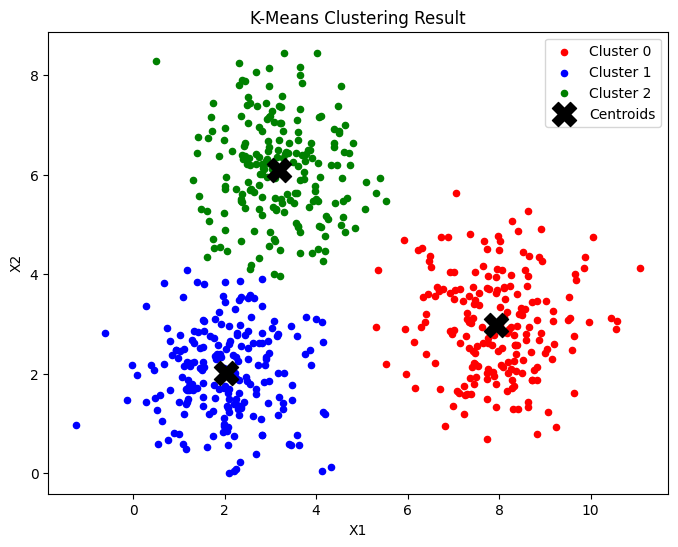

In [12]:
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

for k in range(K):

    plt.scatter(
        X[labels == k][:,0],
        X[labels == k][:,1],
        s=20,
        color=colors[k],
        label=f'Cluster {k}'
    )

# Plot centroids
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    color='black',
    marker='X',
    label='Centroids'
)

plt.title("K-Means Clustering Result")
plt.xlabel("X1")
plt.ylabel("X2")

plt.legend()

plt.show()



Nhận xét:

- Trong K-Means, các centroid ban đầu được khởi tạo ngẫu nhiên nên kết quả phân cụm có thể thay đổi sau mỗi lần chạy.

- Nếu các centroid ban đầu được chọn gần đúng vị trí các cụm thật, thuật toán sẽ hội tụ nhanh và cho kết quả phân cụm tốt.

- Ngược lại, nếu centroid khởi tạo nằm quá gần nhau hoặc nằm xa dữ liệu thực tế, K-Means có thể:
    + Hội tụ chậm hơn
    + Rơi vào local optimum
    + Phân cụm sai
    + Tạo ra cluster rỗng

- Do K-Means tối ưu dựa trên khoảng cách Euclidean nên quá trình khởi tạo centroid ảnh hưởng rất lớn đến chất lượng cuối cùng của mô hình.

- Đây là lý do phương pháp K-Means++ thường được sử dụng để cải thiện bước khởi tạo centroid và tăng độ ổn định của thuật toán.

### Assignment 2 (2 scores):
- Generate a toy dataset having $1200$ points following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma)$, and $1000$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma)$ where $\Sigma = 
\left(\begin{array}{cc}
    1 & 0 \\
    0 & 1
\end{array}\right)
$.
- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of different sizes among clusters to the performance of K-means.

Dataset Shape: (2400, 2)


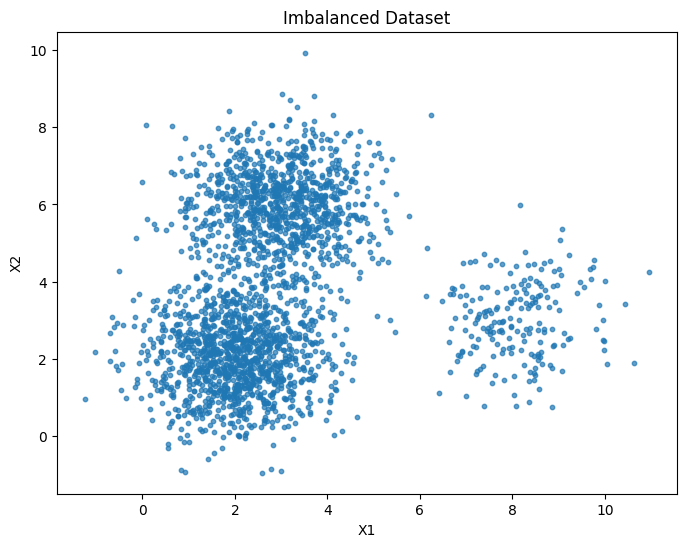

In [13]:
np.random.seed(42)

# Means
mean1 = [2, 2]
mean2 = [8, 3]
mean3 = [3, 6]

# Covariance matrix
cov = [[1, 0],
       [0, 1]]

X1 = np.random.multivariate_normal(mean1, cov, 1200)
X2 = np.random.multivariate_normal(mean2, cov, 200)
X3 = np.random.multivariate_normal(mean3, cov, 1000)

# Combine dataset
X = np.vstack((X1, X2, X3))

print("Dataset Shape:", X.shape)

# Visualize the imbalanced dataset

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    s=10,
    alpha=0.7
)

plt.title("Imbalanced Dataset")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show()

In [14]:
def assign_clusters(X, centroids):

    distances = np.linalg.norm(
        X[:, np.newaxis] - centroids,
        axis=2
    )

    labels = np.argmin(distances, axis=1)

    return labels

def update_centroids(X, labels, K, old_centroids):

    new_centroids = []

    for k in range(K):

        points = X[labels == k]

        # Handle empty cluster
        if len(points) > 0:

            centroid = points.mean(axis=0)

        else:

            centroid = old_centroids[k]

        new_centroids.append(centroid)

    return np.array(new_centroids)

def compute_inertia(X, labels, centroids):

    inertia = 0

    for k in range(len(centroids)):

        cluster_points = X[labels == k]

        inertia += np.sum(
            (cluster_points - centroids[k]) ** 2
        )

    return inertia


def kmeans(X, K, max_iters=100):

    # Random initialization
    random_idx = np.random.choice(
        len(X),
        K,
        replace=False
    )

    centroids = X[random_idx]

    inertia_history = []

    for iteration in range(max_iters):

        # Assign clusters
        labels = assign_clusters(X, centroids)

        # Update centroids
        new_centroids = update_centroids(
            X,
            labels,
            K,
            centroids
        )

        # Compute inertia
        inertia = compute_inertia(
            X,
            labels,
            new_centroids
        )

        inertia_history.append(inertia)

        # Check convergence
        if np.allclose(centroids, new_centroids):

            print(f"Converged at iteration {iteration}")

            break

        centroids = new_centroids

    return labels, centroids, inertia_history

In [15]:
K = 3

labels, centroids, inertia_history = kmeans(X, K)

print("\nFinal Centroids:\n")
print(centroids)

Converged at iteration 5

Final Centroids:

[[8.06821078 3.02085042]
 [2.96376331 5.97673677]
 [2.00111531 2.02081773]]



Inertia: 4536.406716145011
Silhouette Score: 0.5878569143080759


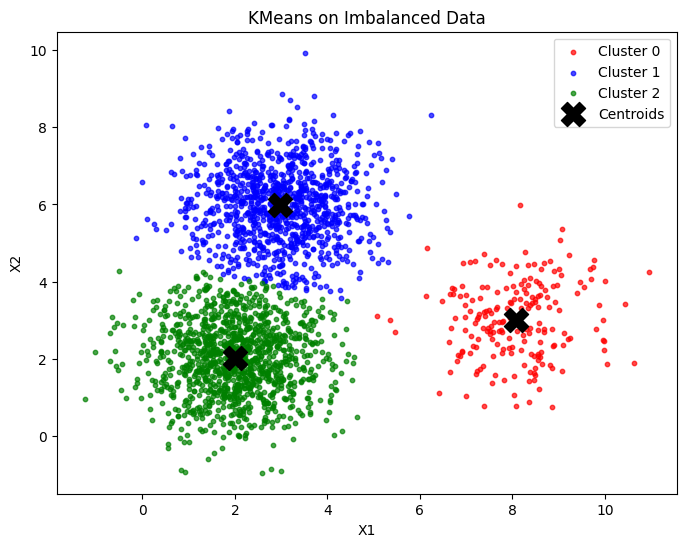

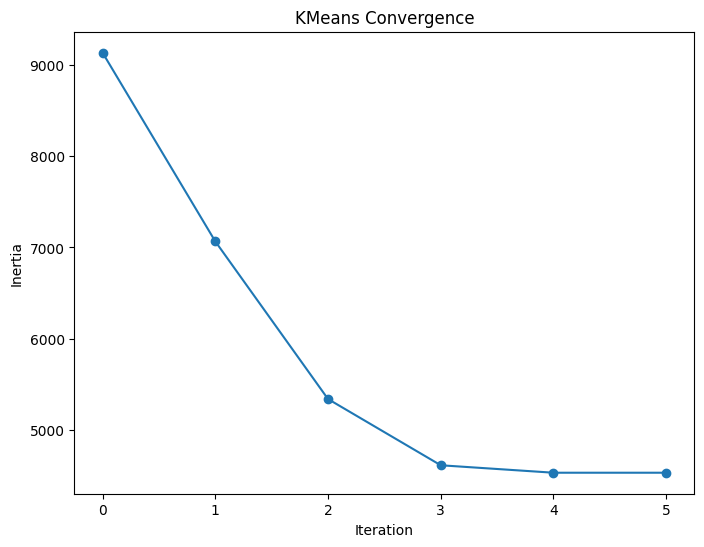

In [16]:
inertia = inertia_history[-1]

print("\nInertia:", inertia)

# Silhouette Score
score = silhouette_score(X, labels)

print("Silhouette Score:", score)

# Visualize clusters

plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

for k in range(K):

    plt.scatter(
        X[labels == k][:,0],
        X[labels == k][:,1],
        s=10,
        color=colors[k],
        alpha=0.7,
        label=f'Cluster {k}'
    )

# Plot centroids
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    color='black',
    marker='X',
    label='Centroids'
)

plt.title("KMeans on Imbalanced Data")
plt.xlabel("X1")
plt.ylabel("X2")

plt.legend()

plt.show()


plt.figure(figsize=(8,6))

plt.plot(
    range(len(inertia_history)),
    inertia_history,
    marker='o'
)

plt.title("KMeans Convergence")
plt.xlabel("Iteration")
plt.ylabel("Inertia")

plt.show()

In [17]:
print("\nCluster Size Analysis:\n")

for k in range(K):

    cluster_size = np.sum(labels == k)

    print(f"Cluster {k}: {cluster_size} points")


Cluster Size Analysis:

Cluster 0: 202 points
Cluster 1: 1005 points
Cluster 2: 1193 points


Nhận xét:

- K-Means hoạt động tốt khi các cluster có kích thước tương đối cân bằng.

- Khi số lượng điểm dữ liệu giữa các cluster chênh lệch lớn, centroid của cluster lớn sẽ có ảnh hưởng mạnh hơn trong quá trình cập nhật tâm cụm.

- Cluster nhỏ có thể:
    + Bị centroid của cluster lớn “lấn át”
    + Bị gộp nhầm vào cluster khác
    + Có ranh giới phân cụm không chính xác

- Trong dataset mất cân bằng, K-Means thường ưu tiên tối thiểu hóa tổng khoảng cách của các cluster lớn hơn thay vì đảm bảo mọi cluster đều được phân tách tốt.

- Điều này cho thấy K-Means khá nhạy với dữ liệu imbalanced và hiệu suất phân cụm có thể giảm khi kích thước các cluster quá khác nhau.

### Assignment 3 (2 scores):

- Generate a toy dataset having $600$ data points, $200$ points of them following the Gaussian distribution $\mathcal{N}((2, 2), \Sigma_1)$, $200$ points of them following the Gaussian distribution $\mathcal{N}((8, 3), \Sigma_1)$, and $200$ points of them following the Gaussian distribution $\mathcal{N}((3, 6), \Sigma_2)$ where 

$$
    \Sigma_1 = 
    \left(\begin{array}{cc}
        1 & 0 \\
        0 & 1
    \end{array}\right)
$$ 

and

$$
\Sigma_2 = 
    \left(\begin{array}{cc}
        10 & 0 \\
        0 & 1
    \end{array}\right)
$$.

- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of distribution $\mathcal{N}((3, 6), \Sigma_2)$ to the performance of K-means.

Dataset Shape: (600, 2)


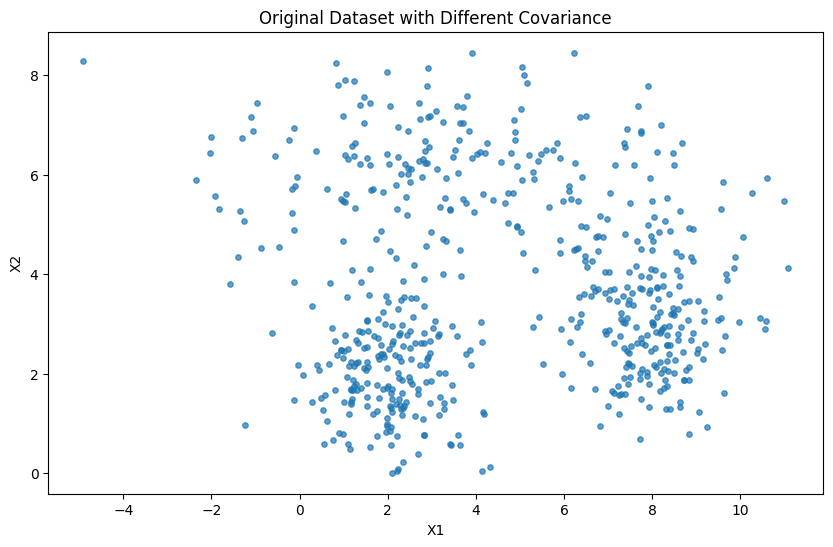

In [18]:
np.random.seed(42)

# Mean vectors
mean1 = [2, 2]
mean2 = [8, 3]
mean3 = [3, 6]

# Covariance matrices
cov1 = [[1, 0],
        [0, 1]]

cov2 = [[10, 0],
        [0, 1]]

# Generate Gaussian clusters
X1 = np.random.multivariate_normal(mean1, cov1, 200)
X2 = np.random.multivariate_normal(mean2, cov1, 200)
X3 = np.random.multivariate_normal(mean3, cov2, 200)

# Combine dataset
X = np.vstack((X1, X2, X3))

print("Dataset Shape:", X.shape)

# Visualize 

plt.figure(figsize=(10,6))

plt.scatter(
    X[:,0],
    X[:,1],
    s=15,
    alpha=0.7
)

plt.title("Original Dataset with Different Covariance")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show()


In [19]:
def assign_clusters(X, centroids):

    # Compute Euclidean distances
    distances = np.linalg.norm(
        X[:, np.newaxis] - centroids,
        axis=2
    )

    # Assign nearest centroid
    labels = np.argmin(distances, axis=1)

    return labels

def update_centroids(X, labels, K, old_centroids):

    new_centroids = []

    for k in range(K):

        points = X[labels == k]

        # Handle empty cluster
        if len(points) > 0:

            centroid = points.mean(axis=0)

        else:

            centroid = old_centroids[k]

        new_centroids.append(centroid)

    return np.array(new_centroids)


def compute_inertia(X, labels, centroids):

    inertia = 0

    for k in range(len(centroids)):

        cluster_points = X[labels == k]

        inertia += np.sum(
            (cluster_points - centroids[k]) ** 2
        )

    return inertia


def kmeans(X, K, max_iters=100):

    # Random initialization
    random_idx = np.random.choice(
        len(X),
        K,
        replace=False
    )

    centroids = X[random_idx]

    inertia_history = []

    # Main loop
    for iteration in range(max_iters):

        # Step 1 — Assign clusters
        labels = assign_clusters(X, centroids)

        # Step 2 — Update centroids
        new_centroids = update_centroids(
            X,
            labels,
            K,
            centroids
        )

        # Compute inertia
        inertia = compute_inertia(
            X,
            labels,
            new_centroids
        )

        inertia_history.append(inertia)

        # Check convergence
        if np.allclose(centroids, new_centroids):

            print(f"Converged at iteration {iteration}")

            break

        centroids = new_centroids

    return labels, centroids, inertia_history

In [20]:
K = 3

labels, centroids, inertia_history = kmeans(X, K)

print("\nFinal Centroids:\n")
print(centroids)

# Inertia
inertia = compute_inertia(
    X,
    labels,
    centroids
)

print("\nInertia:", inertia)

# Silhouette Score
score = silhouette_score(X, labels)

print("Silhouette Score:", score)


Converged at iteration 19

Final Centroids:

[[7.84137863 3.49811562]
 [2.53481065 6.28740649]
 [1.94139558 2.07448304]]

Inertia: 1985.7622680391164
Silhouette Score: 0.551109941297595


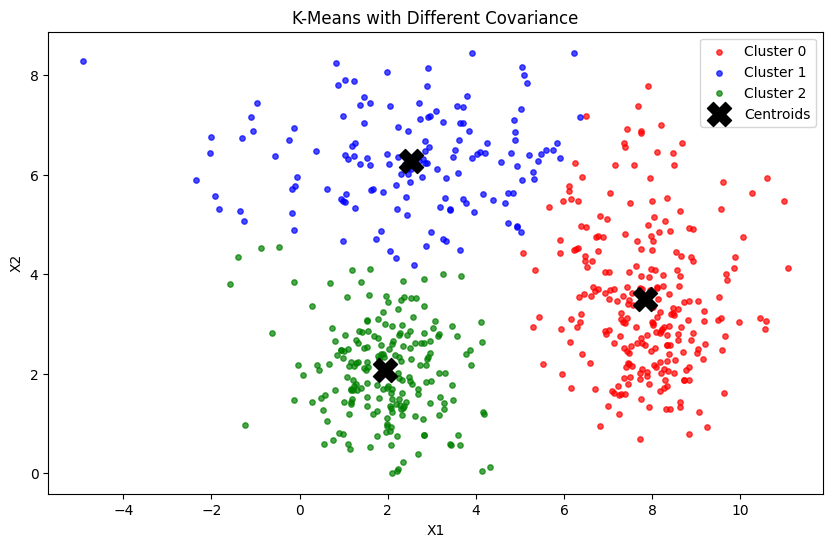

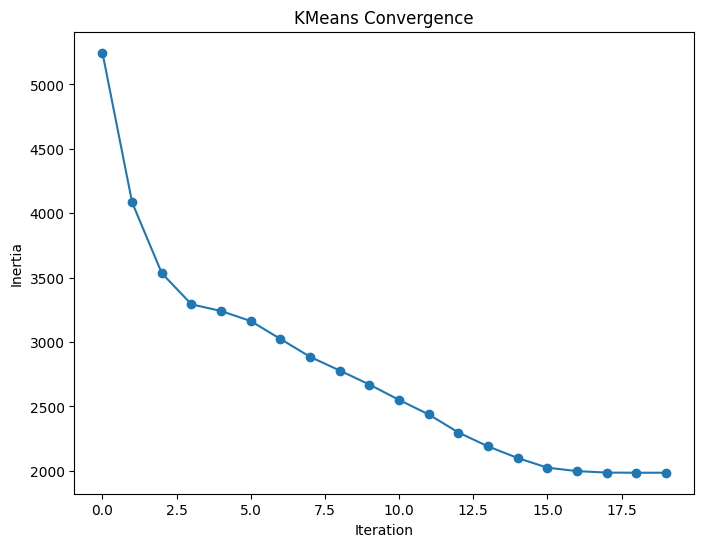


Cluster Size Analysis:

Cluster 0: 248 points
Cluster 1: 147 points
Cluster 2: 205 points


In [21]:
plt.figure(figsize=(10,6))

colors = ['red', 'blue', 'green']

for k in range(K):

    plt.scatter(
        X[labels == k][:,0],
        X[labels == k][:,1],
        s=15,
        color=colors[k],
        alpha=0.7,
        label=f'Cluster {k}'
    )

# Plot centroids
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    color='black',
    marker='X',
    label='Centroids'
)

plt.title("K-Means with Different Covariance")
plt.xlabel("X1")
plt.ylabel("X2")

plt.legend()

plt.show()


plt.figure(figsize=(8,6))

plt.plot(
    range(len(inertia_history)),
    inertia_history,
    marker='o'
)

plt.title("KMeans Convergence")
plt.xlabel("Iteration")
plt.ylabel("Inertia")

plt.show()



print("\nCluster Size Analysis:\n")

for k in range(K):

    cluster_size = np.sum(labels == k)

    print(f"Cluster {k}: {cluster_size} points")

Nhận xét:

- Phân phối Gaussian 𝒩((3,6), Σ₂) có variance lớn theo trục X1 nên tạo ra một cluster kéo dài theo phương ngang.

- Tuy nhiên, K-Means giả định các cluster có dạng hình cầu (spherical clusters) và sử dụng khoảng cách Euclidean để phân cụm.

- Vì cluster thứ ba có hình dạng elongated thay vì hình tròn nên K-Means gặp khó khăn trong việc xác định ranh giới phân cụm chính xác.

- Một số điểm dữ liệu ở vùng kéo dài có thể bị gán nhầm sang cluster khác mặc dù chúng thuộc cùng một phân phối Gaussian.

- Điều này cho thấy K-Means không phù hợp với dữ liệu có covariance khác nhau hoặc cluster có hình dạng phức tạp.

- Trong trường hợp này, Gaussian Mixture Model (GMM) thường cho kết quả tốt hơn vì GMM mô hình hóa trực tiếp ma trận hiệp phương sai của từng cluster.

### Assignment 1 (2 scores):
- Use Numpy only to implement the Gaussian Mixture Model.
- Train Gaussian Mixture Model with EM method.

Dataset Shape: (900, 2)


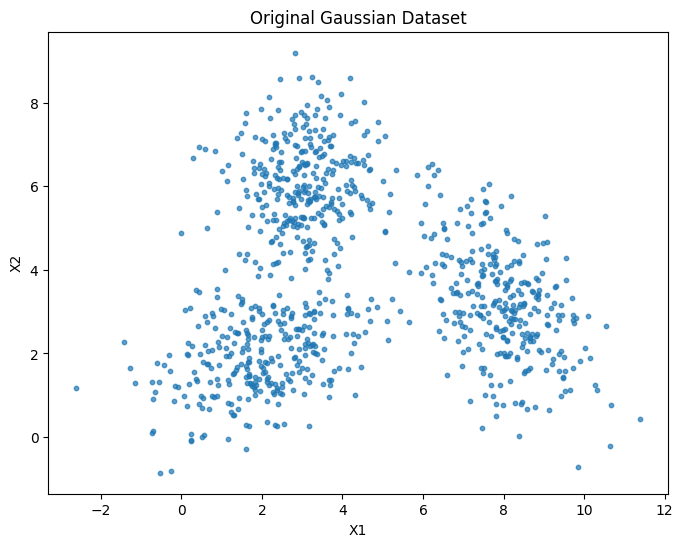

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.metrics import silhouette_score

np.random.seed(42)

# Mean vectors
mean1 = [2, 2]
mean2 = [8, 3]
mean3 = [3, 6]

# Covariance matrices
cov1 = [[2, 0.5],
        [0.5, 1]]

cov2 = [[1, -0.7],
        [-0.7, 2]]

cov3 = [[1, 0],
        [0, 1]]

X1 = np.random.multivariate_normal(mean1, cov1, 300)
X2 = np.random.multivariate_normal(mean2, cov2, 300)
X3 = np.random.multivariate_normal(mean3, cov3, 300)

# Combine dataset
X = np.vstack((X1, X2, X3))

print("Dataset Shape:", X.shape)

# Visualize
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    s=10,
    alpha=0.7
)

plt.title("Original Gaussian Dataset")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show()

In [23]:
N, D = X.shape
K = 3

# Randomly initialize means
means = X[np.random.choice(N, K, replace=False)]

# Initialize covariance matrices
covariances = np.array([
    np.eye(D) for _ in range(K)
])

# Initialize mixing coefficients
weights = np.ones(K) / K

print("\nInitial Means:\n")
print(means)


Initial Means:

[[6.37257629 6.38827159]
 [4.21715852 7.52131605]
 [8.15504589 2.02101242]]


In [24]:
max_iters = 100
tol = 1e-4

# Responsibilities matrix
responsibilities = np.zeros((N, K))

# Store log-likelihood history
log_likelihood_history = []

old_log_likelihood = -np.inf

In [ ]:
for iteration in range(max_iters):
    for k in range(K):

        # Add small value for numerical stability
        safe_cov = covariances[k] + np.eye(D) * 1e-6

        responsibilities[:, k] = (
            weights[k] *
            multivariate_normal(
                mean=means[k],
                cov=safe_cov
            ).pdf(X)
        )

    # Total probability density
    total_pdf = responsibilities.sum(
        axis=1,
        keepdims=True
    )

    # Prevent division by zero
    total_pdf = np.where(
        total_pdf == 0,
        1e-15,
        total_pdf
    )

    # Normalize responsibilities
    responsibilities /= total_pdf

    log_likelihood = np.sum(
        np.log(total_pdf)
    )

    log_likelihood_history.append(log_likelihood)

    # Check convergence
    if np.abs(
        log_likelihood - old_log_likelihood
    ) < tol:

        print(f"\nGMM converged at iteration {iteration}")

        break

    old_log_likelihood = log_likelihood

    # Effective number of points per cluster
    Nk = responsibilities.sum(axis=0)

    # Prevent division by zero
    Nk = np.where(Nk == 0, 1e-15, Nk)

    for k in range(K):
        # Update Means
        means[k] = (
            responsibilities[:, k][:, np.newaxis] * X
        ).sum(axis=0) / Nk[k]

        # Update Covariance Matrices
        diff = X - means[k]

        covariances[k] = (
            responsibilities[:, k][:, np.newaxis] * diff
        ).T @ diff / Nk[k]

        # Update Mixing Coefficients
        weights[k] = Nk[k] / N


GMM converged at iteration 40


In [26]:
labels = np.argmax(
    responsibilities,
    axis=1
)

In [27]:
# Silhouette Score
score = silhouette_score(X, labels)

print("\nSilhouette Score:", score)

# Final Log-Likelihood
print("Final Log-Likelihood:", log_likelihood)

print("\nFinal Means:\n")
print(means)

print("\nFinal Mixing Coefficients:\n")
print(weights)


Silhouette Score: 0.5815817514452495
Final Log-Likelihood: -3616.9856220941547

Final Means:

[[7.96563023 3.17956398]
 [3.01951849 6.09960794]
 [2.00996063 1.97651956]]

Final Mixing Coefficients:

[0.33463812 0.33455521 0.33080666]


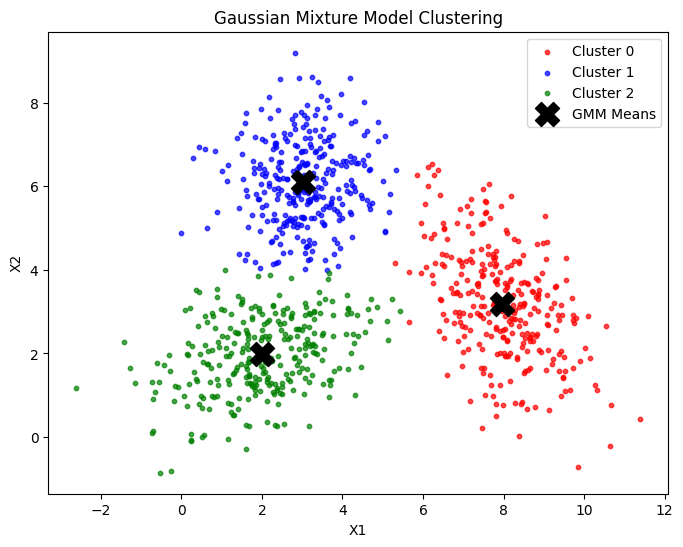

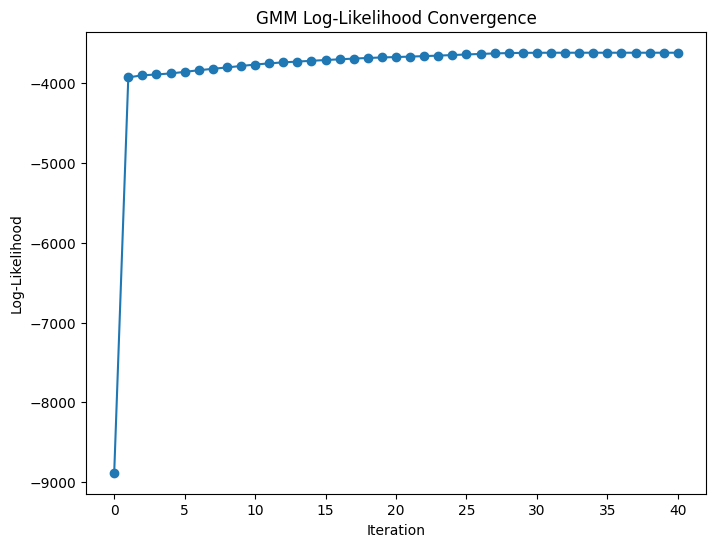


Cluster Size Analysis:

Cluster 0: 301 points
Cluster 1: 302 points
Cluster 2: 297 points


In [ ]:
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green']

for k in range(K):
    plt.scatter(
        X[labels == k][:,0],
        X[labels == k][:,1],
        s=10,
        color=colors[k],
        alpha=0.7,
        label=f'Cluster {k}'
    )

# Plot GMM means
plt.scatter(
    means[:,0],
    means[:,1],
    s=300,
    color='black',
    marker='X',
    label='GMM Means'
)

plt.title("Gaussian Mixture Model Clustering")
plt.xlabel("X1")
plt.ylabel("X2")

plt.legend()

plt.show()

plt.figure(figsize=(8,6))

plt.plot(
    range(len(log_likelihood_history)),
    log_likelihood_history,
    marker='o'
)

plt.title("GMM Log-Likelihood Convergence")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")

plt.show()



print("\nCluster Size Analysis:\n")

for k in range(K):
    cluster_size = np.sum(labels == k)
    print(f"Cluster {k}: {cluster_size} points")


Discussion:

- Gaussian Mixture Model (GMM) is a probabilistic
  clustering algorithm.

- Unlike KMeans, GMM performs soft clustering.

- Each data point has a probability of belonging
  to each Gaussian component.

- GMM can model elliptical clusters because each
  cluster has its own covariance matrix.

- The EM algorithm iteratively updates:
    1. Responsibilities (E-step)
    2. Means, Covariances, and Weights (M-step)

- GMM is more flexible than KMeans for datasets
  with different covariance structures.


### Assignment 2 (2 scores):

Use the Gaussian Mixture Model to filter out background of a given image.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from PIL import Image

Image Shape: (200, 200, 3)


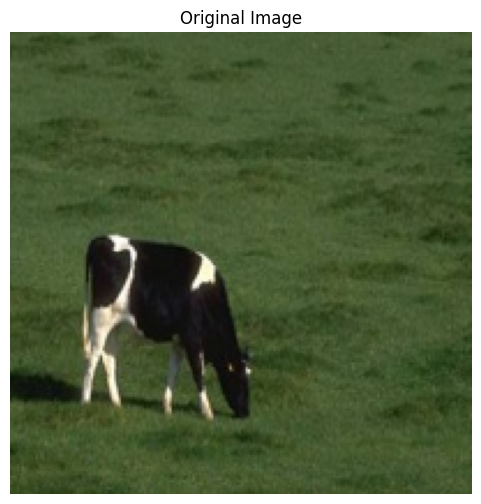

In [30]:
# Đọc ảnh đầu vào
image = Image.open("cow.jpg")

# Resize ảnh để tăng tốc độ tính toán cho GMM
image = image.resize((200, 200))

# Chuyển ảnh thành mảng NumPy
image_np = np.array(image)

print("Image Shape:", image_np.shape)

plt.figure(figsize=(6,6))
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")
plt.show()


In [31]:
# Biến đổi ma trận ảnh thành mảng 2D chứa các pixel RGB (N, 3)
pixels = image_np.reshape(-1, 3)
print("Pixels Shape:", pixels.shape)

# Chuẩn hóa giá trị pixel về đoạn [0, 1] để GMM hội tụ ổn định
pixels = pixels / 255.0

Pixels Shape: (40000, 3)


In [ ]:
# Train
K = 3

gmm = GaussianMixture(
    n_components=K,
    covariance_type='full',
    random_state=42
)

gmm.fit(pixels)
print("\nGMM Training Completed")

# Dự đoán nhãn cho từng pixel

labels = gmm.predict(pixels)
print("Labels Shape:", labels.shape)

In [ ]:
# Khôi phục mảng nhãn phẳng về kích thước ảnh gốc (H, W)
segmented_labels = labels.reshape(
    image_np.shape[0],
    image_np.shape[1]
)

plt.figure(figsize=(6,6))
plt.imshow(segmented_labels, cmap='viridis')
plt.title("Segmented Label Map (Cluster Indices)")
plt.axis("off")
plt.show()

In [ ]:
# Thay thế màu của từng pixel bằng màu trung bình (mean) của cụm đó
segmented_pixels = gmm.means_[labels]

# Reshape quay lại cấu trúc ảnh (H, W, C)
segmented_image = segmented_pixels.reshape(image_np.shape)

# Chuyển ngược dữ liệu về đoạn [0, 255] và ép kiểu sang uint8 để hiển thị ảnh
segmented_image = (segmented_image * 255).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(segmented_image)
plt.title("Segmented RGB Image (Color Quantization)")
plt.axis("off")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, K, figsize=(15, 5))
for k in range(K):
    cluster_img = np.zeros_like(image_np)
    cluster_img[segmented_labels == k] = image_np[segmented_labels == k]
    axes[k].imshow(cluster_img)
    axes[k].set_title(f"Cluster {k}")
    axes[k].axis("off")
plt.suptitle("Visualizing Each Cluster Individually", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Dựa vào đồ thị trực quan ở STEP 10, hãy xác định nhãn nào là NỀN (Cỏ/Bầu trời).
# Bạn hãy thay đổi giá trị của `background_label` bên dưới (0, 1 hoặc 2) cho đúng với ảnh của bạn.
background_label = 2 

# Tạo mặt nạ chứa các vị trí KHÔNG PHẢI LÀ NỀN (Foreground Mask)
foreground_mask = (segmented_labels != background_label)

# Sao chép ảnh gốc và chuyển toàn bộ vùng nền thành màu đen [0, 0, 0]
filtered_image = image_np.copy()
filtered_image[~foreground_mask] = [0, 0, 0]

plt.figure(figsize=(12, 6))

# Ảnh gốc
plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

# Ảnh đã lọc bỏ nền
plt.subplot(1, 2, 2)
plt.imshow(filtered_image)
plt.title("Background Filtered Image (GMM)")
plt.axis("off")

plt.show()



print("\nGMM Means (Normalized RGB Colors):\n")
print(gmm.means_)

print("\nMixing Coefficients (Cluster Weights):\n")
print(gmm.weights_)


Discussion:

- Gaussian Mixture Model (GMM) is successfully used to cluster pixels in RGB color space.
- Pixels are represented as [R, G, B] vectors, normalized to the range [0, 1] for numerical stability.
- GMM effectively groups variations of similar colors (shadows, highlights on the background) into distinct 
  Gaussian components thanks to its flexible 'full' covariance matrix setup.
- The 'Segmented RGB Image' achieves Color Quantization by replacing every pixel with its component's mean color.
- By visualizing individual components, the background cluster is identified and masked out (set to black), 
  effectively fulfilling the image filtering assignment.
- A core limitation is the lack of spatial awareness: GMM only considers color information, so background pixels 
  that share identical RGB profiles with the foreground object may accidentally be preserved or filtered out.
